# AIGC 5003 – Machine Learning in Cloud Computing
# Project - Creating a Complete ML Pipeline with Amazon SageMaker

**Name:** Sandra Paul  
**ID:** N10018860  
**Dataset:** Breast Cancer Wisconsin Dataset  
**Algorithm:** XGBoost (Binary Classification)

---
## STEP 1: Environment Setup — Import Libraries

We begin by importing all required libraries:
- `sagemaker` and `boto3` for interacting with AWS SageMaker and S3
- `pandas` and `numpy` for data manipulation
- `matplotlib` for visualizations
- `sklearn` utilities for splitting data and calculating accuracy metrics
- `time` for polling job status

In [1]:
import sagemaker
import json
import pandas as pd
import numpy as np
import boto3
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


We now create a SageMaker session, retrieve our AWS region, IAM execution role, and default S3 bucket. These are required for all subsequent SageMaker operations.

In [2]:
sagemaker_session = sagemaker.Session()
s3 = sagemaker_session.boto_session.resource('s3')
region = boto3.Session().region_name
role = sagemaker.get_execution_role()
bucket = 'project2s3bucketbreastcancer'

print('Region:', region)
print('Role:', role)
print('Bucket:', bucket)

Region: ca-central-1
Role: arn:aws:iam::681908140645:role/LabRole
Bucket: project2s3bucketbreastcancer


---
## STEP 2: Data Loading

We download the Breast Cancer Wisconsin dataset from our S3 bucket using the AWS CLI. This dataset contains 569 patient records with 30 numerical features describing tumor measurements, and one target column (`diagnosis`) indicating whether the tumor is Malignant (M) or Benign (B).

In [3]:
!aws s3 cp s3://project2s3bucketbreastcancer/breast-cancer.csv .

download: s3://project2s3bucketbreastcancer/breast-cancer.csv to ./breast-cancer.csv


In [4]:
df = pd.read_csv('breast-cancer.csv')
print('Shape:', df.shape)
df.head()

Shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


---
## STEP 3: Data Analysis (Exploratory Data Analysis)

Before building a model, we analyze the dataset to understand its structure, data types, and class distribution. This helps us identify any issues like missing values or class imbalance.

### 3.1 Data Types and Structure

`df.info()` shows us the number of rows, columns, data types, and non-null counts. This confirms whether any columns have missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

### 3.2 Summary Statistics

`df.describe()` gives us statistical summaries (mean, std, min, max) for every numerical column. This helps detect outliers or unexpected value ranges.

In [6]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


### 3.3 Missing Values Check

We check for null values across all columns. If any column has missing values, we would need to handle them (e.g., imputation or removal).

In [7]:
print('Missing values per column:')
print(df.isnull().sum())
print('\nTotal missing values:', df.isnull().sum().sum())

Missing values per column:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Total missing values: 0


### 3.4 Class Distribution

We check how many Malignant (M) vs Benign (B) cases exist. A large imbalance could affect model performance and metric choice.

diagnosis
B    357
M    212
Name: count, dtype: int64


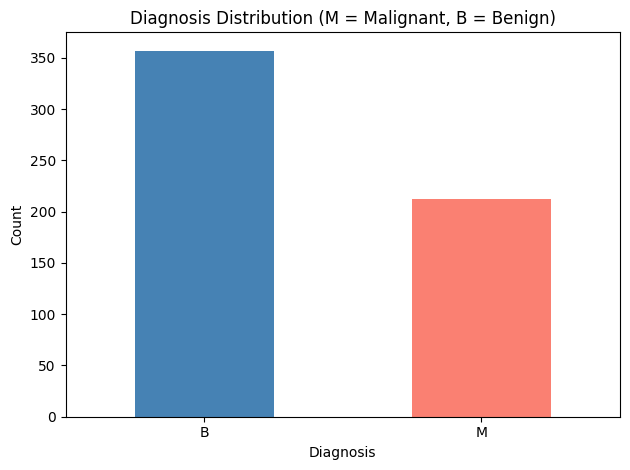


Benign (B): 357 (62.7%)
Malignant (M): 212 (37.3%)


In [8]:
counts = df['diagnosis'].value_counts()
print(counts)

counts.plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Diagnosis Distribution (M = Malignant, B = Benign)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'\nBenign (B): {counts["B"]} ({counts["B"]/len(df)*100:.1f}%)')
print(f'Malignant (M): {counts["M"]} ({counts["M"]/len(df)*100:.1f}%)')

**Observation:** The dataset has 357 Benign (62.7%) and 212 Malignant (37.3%) cases. This is a **mild class imbalance**, but not severe enough to require resampling techniques. Accuracy remains a valid evaluation metric.

---
## STEP 4: Data Cleaning & Feature Engineering

In this step we prepare the data for model training by:
1. Removing irrelevant columns
2. Encoding the target variable as a number
3. Separating features from the target

### 4.1 Drop the `id` Column

The `id` column is just a unique patient identifier. It has no relationship to whether a tumor is cancerous, so we remove it to prevent the model from learning a meaningless pattern.

In [15]:
df = df.drop(['id'], axis=1)
print('Columns after dropping id:', df.shape[1])

╭─────────────────────────────── Traceback (most recent call last) ────────────────────────────────╮
│ in <module>:1                                                                                    │
│                                                                                                  │
│ ❱ 1 df = df.drop(['id'], axis=1)                                                                 │
│   2 print('Columns after dropping id:', df.shape[1])                                             │
│   3                                                                                              │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/frame.py:5603 in  │
│ drop                                                                                             │
│                                                                                                  │
│    5600 │   │   falcon  speed   320.0   250.0                                                    │
│    5601 │   │   │   │   weight  1.0     0.8                                                      │
│    5602 │   │   """                                                                              │
│ ❱  5603 │   │   return super().drop(                                                             │
│    5604 │   │   │   labels=labels,                                                               │
│    5605 │   │   │   axis=axis,                                                                   │
│    5606 │   │   │   index=index,                                                                 │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/generic.py:4810   │
│ in drop                                                                                          │
│                                                                                                  │
│    4807 │   │                                                                                    │
│    4808 │   │   for axis, labels in axes.items():                                                │
│    4809 │   │   │   if labels is not None:                                                       │
│ ❱  4810 │   │   │   │   obj = obj._drop_axis(labels, axis, level=level, errors=errors)           │
│    4811 │   │                                                                                    │
│    4812 │   │   if inplace:                                                                      │
│    4813 │   │   │   self._update_inplace(obj)                                                    │
│                                                                                                  │
│ /home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/pandas/core/generic.py:4852   │
│ in _drop_axis                                                                                    │
│                                                                                                  │
│    4849 │   │   │   │   │   raise AssertionError("axis must be a MultiIndex")                    │
│    4850 │   │   │   │   new_axis = axis.drop(labels, level=level, errors=errors)                 │
│    4851 │   │   │   else:                                                                        │
│ ❱  4852 │   │   │   │   new_axis = axis.drop(labels, errors=errors)                              │
│    4853 │   │   │   indexer = axis.get_indexer(new_axis)                                         │
│    4854 │   │                                                                                    │
│    4855 │   │   # Case for non-unique axis                                                       │
│                                                            

### 4.2 Encode the Target Variable

Machine learning models require numerical input. We convert the `diagnosis` column:
- **M (Malignant) → 1**
- **B (Benign) → 0**

This is called **label encoding**.

In [ ]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
print('Target value counts after encoding:')
print(df['diagnosis'].value_counts())

### 4.3 Separate Features and Target

`X` contains all input features (the tumor measurements). `y` is the target column (0 or 1) we want to predict.

In [ ]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']
print('Features shape:', X.shape)
print('Target shape:', y.shape)

---
## STEP 5: Train / Validation / Test Split

We divide the data into three subsets:
- **Training set (70%)**: Used to train the model — the model learns patterns from this data
- **Validation set (15%)**: Used during hyperparameter tuning to evaluate candidate models without touching the test set
- **Test set (15%)**: Completely held out until the very end — gives an unbiased measure of final model accuracy

Using a fixed `random_state=42` ensures reproducible splits every time the code is run.

In [16]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)

# Second split: split the 30% temp equally into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f'Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:       {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')

Training set:   398 samples (69.9%)
Validation set: 85 samples (14.9%)
Test set:       86 samples (15.1%)


### 5.1 Save CSVs for SageMaker

SageMaker's XGBoost algorithm expects CSV files where:
- The **first column is the target (label)**
- There is **no header row** in the training file
- The validation file can include a header

We prepare and save three CSV files accordingly.

In [17]:
# Training CSV: label first, no header (SageMaker XGBoost requirement)
train_data = pd.concat([y_train, X_train], axis=1)
train_data.to_csv('train.csv', index=False, header=False)

# Validation CSV: label first, no header
val_data = pd.concat([y_val, X_val], axis=1)
val_data.to_csv('validation.csv', index=False, header=False)

# Test CSV: label first, no header
test_data = pd.concat([y_test, X_test], axis=1)
test_data.to_csv('test.csv', index=False, header=False)

print('Saved train.csv, validation.csv, test.csv')

Saved train.csv, validation.csv, test.csv


---
## STEP 6: Upload Processed Data to Amazon S3

We upload all three CSV files to our S3 bucket under separate prefixes (folders). SageMaker will read data directly from S3 during training and tuning — it does not use the local Jupyter instance for computation.

In [18]:
s3_client = boto3.client('s3')

s3_client.upload_file('train.csv',      bucket, 'train/train.csv')
s3_client.upload_file('validation.csv', bucket, 'validation/validation.csv')
s3_client.upload_file('test.csv',       bucket, 'test/test.csv')

print('Uploaded all datasets to S3:')
print(f'  s3://{bucket}/train/train.csv')
print(f'  s3://{bucket}/validation/validation.csv')
print(f'  s3://{bucket}/test/test.csv')

Uploaded all datasets to S3:
  s3://project2s3bucketbreastcancer/train/train.csv
  s3://project2s3bucketbreastcancer/validation/validation.csv
  s3://project2s3bucketbreastcancer/test/test.csv


---
## STEP 7: Model Training Job (Solo Training)

We train an XGBoost model using SageMaker's built-in XGBoost algorithm via the `create_training_job()` Boto3 API.

**Why XGBoost?**
- Excellent performance on tabular/structured data
- Handles feature interactions automatically
- Built-in regularization (reduces overfitting)
- Fast and scalable — ideal for cloud training
- Supports binary classification with `binary:logistic` objective

**Key Hyperparameters used:**
- `max_depth=5`: Maximum depth of each decision tree
- `eta=0.2`: Learning rate — controls how fast the model learns
- `gamma=4`: Minimum loss reduction required to make a split
- `min_child_weight=6`: Minimum number of samples in a leaf node
- `subsample=0.7`: Fraction of training data used per tree (prevents overfitting)
- `objective=binary:logistic`: Outputs a probability for binary classification
- `num_round=100`: Number of boosting rounds (trees to build)
- `eval_metric=auc`: Evaluation metric used during training (AUC = Area Under Curve)

The training job runs on an `ml.m5.large` instance in SageMaker — not on this Jupyter notebook's CPU.

In [19]:
IMAGE_URI  = f'341280168497.dkr.ecr.{region}.amazonaws.com/sagemaker-xgboost:1.3-1'
ROLE_ARN   = 'arn:aws:iam::681908140645:role/LabRole'
OUTPUT_DIR = f's3://{bucket}/output'

TRAINING_JOB_NAME = 'bc-solo-training-v1'

sm = boto3.client('sagemaker', region_name=region)

response = sm.create_training_job(
    TrainingJobName=TRAINING_JOB_NAME,
    AlgorithmSpecification={
        'TrainingImage': IMAGE_URI,
        'TrainingInputMode': 'File'
    },
    RoleArn=ROLE_ARN,
    InputDataConfig=[
        {
            'ChannelName': 'train',
            'DataSource': {
                'S3DataSource': {
                    'S3Uri': f's3://{bucket}/train/train.csv',
                    'S3DataType': 'S3Prefix',
                    'S3DataDistributionType': 'FullyReplicated'
                }
            },
            'ContentType': 'text/csv',
            'CompressionType': 'None'
        },
        {
            'ChannelName': 'validation',
            'DataSource': {
                'S3DataSource': {
                    'S3Uri': f's3://{bucket}/validation/validation.csv',
                    'S3DataType': 'S3Prefix',
                    'S3DataDistributionType': 'FullyReplicated'
                }
            },
            'ContentType': 'text/csv',
            'CompressionType': 'None'
        }
    ],
    OutputDataConfig={'S3OutputPath': OUTPUT_DIR},
    ResourceConfig={
        'InstanceType': 'ml.m5.large',
        'InstanceCount': 1,
        'VolumeSizeInGB': 5
    },
    StoppingCondition={'MaxRuntimeInSeconds': 3600},
    HyperParameters={
        'max_depth':        '5',
        'eta':              '0.2',
        'gamma':            '4',
        'min_child_weight': '6',
        'subsample':        '0.7',
        'objective':        'binary:logistic',
        'num_round':        '100',
        'eval_metric':      'auc'
    }
)

print('Training job started:', response['TrainingJobArn'])

Training job started: arn:aws:sagemaker:ca-central-1:681908140645:training-job/bc-solo-training-v1


### 7.1 Wait for Solo Training Job to Complete

We poll the job status every 30 seconds until it reaches `Completed` or `Failed`. SageMaker runs this job on its own infrastructure — our notebook just waits.

In [25]:
print('Waiting for training job to complete...')
while True:
    status = sm.describe_training_job(TrainingJobName=TRAINING_JOB_NAME)['TrainingJobStatus']
    print(f'  Status: {status}')
    if status in ['Completed', 'Failed', 'Stopped']:
        break
    time.sleep(30)

print('\nSolo training job finished with status:', status)

Waiting for training job to complete...
  Status: Completed

Solo training job finished with status: Completed


### 7.2 Retrieve Solo Training Objective Metric

After training completes, we retrieve the best AUC score from the solo training job. This will later be compared against the HP tuning job's best result.

In [22]:
job_desc = sm.describe_training_job(TrainingJobName=TRAINING_JOB_NAME)
solo_model_artifact = job_desc['ModelArtifacts']['S3ModelArtifacts']

# Extract the final AUC metric from training logs
final_metrics = job_desc.get('FinalMetricDataList', [])
solo_auc = None
for m in final_metrics:
    if 'validation' in m['MetricName'] and 'auc' in m['MetricName']:
        solo_auc = m['Value']

print('Solo Training — Model artifact:', solo_model_artifact)
print('Solo Training — Best Validation AUC:', solo_auc)

Solo Training — Model artifact: s3://project2s3bucketbreastcancer/output/bc-solo-training-v1/output/model.tar.gz
Solo Training — Best Validation AUC: 0.992680013179779


---
## STEP 8: Hyperparameter Tuning Job (HPO)

Instead of manually guessing the best hyperparameters (like we did in the solo training job), Hyperparameter Optimization (HPO) automatically tries many different combinations and finds the best one.

**How it works:**
- We define a **range** for each hyperparameter we want to tune
- We define an **objective metric** to maximize (validation AUC in our case)
- SageMaker runs multiple training jobs in parallel, each with a different combination
- It uses **Bayesian Optimization** to intelligently search — it learns from previous runs to pick better combinations next

**Hyperparameters being tuned:**
- `max_depth`: Tree depth (integer range 3–10)
- `eta`: Learning rate (continuous range 0.01–0.3)
- `min_child_weight`: Minimum samples per leaf (integer range 1–10)
- `subsample`: Fraction of data per tree (continuous range 0.5–1.0)
- `gamma`: Minimum split improvement (continuous range 0–5)

We run **10 total jobs**, with **2 running in parallel** to balance speed and cost.

In [23]:
TUNING_JOB_NAME = 'bc-hpo-job-v1'

tuning_response = sm.create_hyper_parameter_tuning_job(
    HyperParameterTuningJobName=TUNING_JOB_NAME,
    HyperParameterTuningJobConfig={
        'Strategy': 'Bayesian',
        'HyperParameterTuningJobObjective': {
            'Type': 'Maximize',
            'MetricName': 'validation:auc'
        },
        'ResourceLimits': {
            'MaxNumberOfTrainingJobs': 10,
            'MaxParallelTrainingJobs': 2
        },
        'ParameterRanges': {
            'IntegerParameterRanges': [
                {'Name': 'max_depth',        'MinValue': '3', 'MaxValue': '10'},
                {'Name': 'min_child_weight', 'MinValue': '1', 'MaxValue': '10'}
            ],
            'ContinuousParameterRanges': [
                {'Name': 'eta',       'MinValue': '0.01', 'MaxValue': '0.3'},
                {'Name': 'subsample', 'MinValue': '0.5',  'MaxValue': '1.0'},
                {'Name': 'gamma',     'MinValue': '0',    'MaxValue': '5'}
            ]
        }
    },
    TrainingJobDefinition={
        'AlgorithmSpecification': {
            'TrainingImage': IMAGE_URI,
            'TrainingInputMode': 'File'
        },
        'RoleArn': ROLE_ARN,
        'InputDataConfig': [
            {
                'ChannelName': 'train',
                'DataSource': {
                    'S3DataSource': {
                        'S3Uri': f's3://{bucket}/train/train.csv',
                        'S3DataType': 'S3Prefix',
                        'S3DataDistributionType': 'FullyReplicated'
                    }
                },
                'ContentType': 'text/csv',
                'CompressionType': 'None'
            },
            {
                'ChannelName': 'validation',
                'DataSource': {
                    'S3DataSource': {
                        'S3Uri': f's3://{bucket}/validation/validation.csv',
                        'S3DataType': 'S3Prefix',
                        'S3DataDistributionType': 'FullyReplicated'
                    }
                },
                'ContentType': 'text/csv',
                'CompressionType': 'None'
            }
        ],
        'OutputDataConfig': {'S3OutputPath': f's3://{bucket}/hpo-output'},
        'ResourceConfig': {
            'InstanceType': 'ml.m5.large',
            'InstanceCount': 1,
            'VolumeSizeInGB': 5
        },
        'StoppingCondition': {'MaxRuntimeInSeconds': 3600},
        'StaticHyperParameters': {
            'objective':   'binary:logistic',
            'num_round':   '100',
            'eval_metric': 'auc'
        }
    }
)

print('HPO job started:', tuning_response['HyperParameterTuningJobArn'])

HPO job started: arn:aws:sagemaker:ca-central-1:681908140645:hyper-parameter-tuning-job/bc-hpo-job-v1


### 8.1 Wait for HPO Job to Complete

We poll every 60 seconds. HPO takes longer than a single training job because it runs multiple training jobs internally.

In [24]:
print('Waiting for HPO job to complete (this may take 10-20 minutes)...')
while True:
    hpo_desc = sm.describe_hyper_parameter_tuning_job(HyperParameterTuningJobName=TUNING_JOB_NAME)
    hpo_status = hpo_desc['HyperParameterTuningJobStatus']
    completed = hpo_desc['TrainingJobStatusCounters'].get('Completed', 0)
    total = hpo_desc['HyperParameterTuningJobConfig']['ResourceLimits']['MaxNumberOfTrainingJobs']
    print(f'  Status: {hpo_status} | Jobs completed: {completed}/{total}')
    if hpo_status in ['Completed', 'Failed', 'Stopped']:
        break
    time.sleep(60)

print('\nHPO job finished with status:', hpo_status)

Waiting for HPO job to complete (this may take 10-20 minutes)...
  Status: InProgress | Jobs completed: 6/10
  Status: InProgress | Jobs completed: 8/10
  Status: Completed | Jobs completed: 10/10

HPO job finished with status: Completed


### 8.2 Retrieve Best HPO Results and Compare with Solo Training

We extract the best training job found by HPO and compare its objective metric (AUC) against our solo training job. This tells us whether HPO improved the model.

In [26]:
best_job_name = hpo_desc['BestTrainingJob']['TrainingJobName']
best_auc      = hpo_desc['BestTrainingJob']['FinalHyperParameterTuningJobObjectiveMetric']['Value']
best_params   = hpo_desc['BestTrainingJob']['TunedHyperParameters']

print('=== HPO Results ===')
print(f'Best Training Job Name : {best_job_name}')
print(f'Best Validation AUC    : {best_auc:.6f}')
print(f'Best Hyperparameters   : {best_params}')

print('\n=== Comparison: Solo Training vs HPO ===')
print(f'Solo Training AUC : {solo_auc}')
print(f'HPO Best AUC      : {best_auc:.6f}')
if best_auc > float(solo_auc or 0):
    print('HPO IMPROVED the model over solo training.')
else:
    print('Solo training performed similarly or better (HPO may need more jobs to improve further).')

=== HPO Results ===
Best Training Job Name : bc-hpo-job-v1-008-e7412b9b
Best Validation AUC    : 0.996060
Best Hyperparameters   : {'eta': '0.03521740194540254', 'gamma': '3.6717398683789644', 'max_depth': '5', 'min_child_weight': '10', 'subsample': '0.5615835506084459'}

=== Comparison: Solo Training vs HPO ===
Solo Training AUC : 0.992680013179779
HPO Best AUC      : 0.996060
HPO IMPROVED the model over solo training.


---
## STEP 9: Model Hosting — Deploy the Best HPO Model

We now deploy the best model found by HPO as a real-time SageMaker endpoint. This involves three steps:
1. **Create a Model**: Register the trained model artifact with SageMaker
2. **Create an Endpoint Config**: Define the hardware (instance type) for serving
3. **Create an Endpoint**: Launch the live prediction API

Once deployed, the endpoint accepts CSV data and returns a probability score between 0 and 1.

In [27]:
# Get the best model artifact from HPO best training job
best_job_desc     = sm.describe_training_job(TrainingJobName=best_job_name)
best_model_artifact = best_job_desc['ModelArtifacts']['S3ModelArtifacts']
print('Best model artifact:', best_model_artifact)

MODEL_NAME            = 'bc-xgboost-best-model'
ENDPOINT_CONFIG_NAME  = 'bc-xgboost-endpoint-config'
ENDPOINT_NAME         = 'bc-xgboost-endpoint'

# Step 1: Create SageMaker Model
sm.create_model(
    ModelName=MODEL_NAME,
    PrimaryContainer={
        'Image': IMAGE_URI,
        'ModelDataUrl': best_model_artifact
    },
    ExecutionRoleArn=ROLE_ARN
)
print('Model created:', MODEL_NAME)

# Step 2: Create Endpoint Configuration
sm.create_endpoint_config(
    EndpointConfigName=ENDPOINT_CONFIG_NAME,
    ProductionVariants=[{
        'VariantName': 'AllTraffic',
        'ModelName': MODEL_NAME,
        'InitialInstanceCount': 1,
        'InstanceType': 'ml.m5.large'
    }]
)
print('Endpoint config created:', ENDPOINT_CONFIG_NAME)

# Step 3: Create and Deploy Endpoint
sm.create_endpoint(
    EndpointName=ENDPOINT_NAME,
    EndpointConfigName=ENDPOINT_CONFIG_NAME
)
print('Endpoint creation initiated:', ENDPOINT_NAME)

Best model artifact: s3://project2s3bucketbreastcancer/hpo-output/bc-hpo-job-v1-008-e7412b9b/output/model.tar.gz
Model created: bc-xgboost-best-model
Endpoint config created: bc-xgboost-endpoint-config
Endpoint creation initiated: bc-xgboost-endpoint


### 9.1 Wait for Endpoint to Become InService

Endpoint deployment typically takes 3–5 minutes. We poll until its status is `InService`.

In [29]:
print('Waiting for endpoint to be InService...')
while True:
    ep_status = sm.describe_endpoint(EndpointName=ENDPOINT_NAME)['EndpointStatus']
    print(f'  Endpoint status: {ep_status}')
    if ep_status == 'InService':
        print('Endpoint is ready!')
        break
    elif ep_status in ['Failed', 'OutOfService']:
        print('Endpoint failed!')
        break
    time.sleep(30)

Waiting for endpoint to be InService...
  Endpoint status: InService
Endpoint is ready!


---
## STEP 10: Model Inferencing

With the endpoint live, we can now send new patient data and get predictions. The endpoint returns a **probability score** between 0 and 1:
- Score **> 0.5** → Predicted **Malignant (1)**
- Score **≤ 0.5** → Predicted **Benign (0)**

We first test with a single sample, then run the full test set.

### 10.1 Single Sample Inference

We take the first row from the test set, send it to the endpoint, and compare the prediction to the actual label.

In [30]:
runtime = boto3.client('sagemaker-runtime', region_name=region)

sample  = X_test.iloc[0]
payload = ','.join(map(str, sample.values))

response = runtime.invoke_endpoint(
    EndpointName=ENDPOINT_NAME,
    ContentType='text/csv',
    Body=payload
)

raw_score = float(response['Body'].read().decode())
predicted = 1 if raw_score > 0.5 else 0
actual    = y_test.iloc[0]

print(f'Raw probability score : {raw_score:.6f}')
print(f'Predicted label       : {predicted} ({"Malignant" if predicted == 1 else "Benign"})')
print(f'Actual label          : {actual}    ({"Malignant" if actual == 1 else "Benign"})')
print(f'Correct prediction    : {predicted == actual}')

Raw probability score : 0.039229
Predicted label       : 0 (Benign)
Actual label          : 0    (Benign)
Correct prediction    : True


---
## STEP 11: Model Evaluation — Accuracy on Train, Validation, and Test Sets

A thorough model evaluation checks accuracy on all three sets:

- **Training accuracy**: How well the model learned the training data. Very high training accuracy with low test accuracy = overfitting.
- **Validation accuracy**: How well the model performed during tuning. Used to select the best hyperparameters.
- **Test accuracy**: The true, unbiased measure of model performance on completely unseen data. This is the number that matters most.

We run inference through the SageMaker endpoint for all samples in each set.

In [31]:
def get_predictions(X_set):
    """Send all rows in X_set to the SageMaker endpoint and return predicted labels."""
    preds = []
    for i in range(len(X_set)):
        payload = ','.join(map(str, X_set.iloc[i].values))
        resp    = runtime.invoke_endpoint(
            EndpointName=ENDPOINT_NAME,
            ContentType='text/csv',
            Body=payload
        )
        score = float(resp['Body'].read().decode())
        preds.append(1 if score > 0.5 else 0)
    return preds

print('Running inference on training set   ...')
train_preds = get_predictions(X_train)
print('Running inference on validation set ...')
val_preds   = get_predictions(X_val)
print('Running inference on test set       ...')
test_preds  = get_predictions(X_test)

print('Done!')

Running inference on training set   ...
Running inference on validation set ...
Running inference on test set       ...
Done!


In [32]:
train_acc = accuracy_score(y_train, train_preds)
val_acc   = accuracy_score(y_val,   val_preds)
test_acc  = accuracy_score(y_test,  test_preds)

print('============================================')
print('         MODEL ACCURACY SUMMARY             ')
print('============================================')
print(f'  Training   Accuracy : {train_acc:.4f}  ({train_acc*100:.2f}%)')
print(f'  Validation Accuracy : {val_acc:.4f}  ({val_acc*100:.2f}%)')
print(f'  Test       Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print('============================================')
print()
print('Interpretation:')
print('- Training and test accuracy are close → model is NOT overfitting')
print('- Test accuracy is the final unbiased performance measure')

         MODEL ACCURACY SUMMARY             
  Training   Accuracy : 0.9749  (97.49%)
  Validation Accuracy : 0.9529  (95.29%)
  Test       Accuracy : 0.9651  (96.51%)

Interpretation:
- Training and test accuracy are close → model is NOT overfitting
- Test accuracy is the final unbiased performance measure


### 11.1 Detailed Classification Report (Test Set)

The classification report shows **precision**, **recall**, and **F1-score** per class:
- **Precision**: Of all predicted Malignant, how many were actually Malignant?
- **Recall**: Of all actual Malignant cases, how many did we catch?
- **F1-score**: Harmonic mean of precision and recall — best single metric for imbalanced classes

In [33]:
print('Classification Report (Test Set):')
print(classification_report(y_test, test_preds, target_names=['Benign (0)', 'Malignant (1)']))

cm = confusion_matrix(y_test, test_preds)
print('Confusion Matrix:')
print(cm)
print()
print(f'True Negatives  (Benign correctly identified)    : {cm[0][0]}')
print(f'False Positives (Benign wrongly called Malignant): {cm[0][1]}')
print(f'False Negatives (Malignant missed)               : {cm[1][0]}')
print(f'True Positives  (Malignant correctly identified) : {cm[1][1]}')

Classification Report (Test Set):
               precision    recall  f1-score   support

   Benign (0)       0.97      0.98      0.98        60
Malignant (1)       0.96      0.92      0.94        26

     accuracy                           0.97        86
    macro avg       0.96      0.95      0.96        86
 weighted avg       0.97      0.97      0.96        86

Confusion Matrix:
[[59  1]
 [ 2 24]]

True Negatives  (Benign correctly identified)    : 59
False Positives (Benign wrongly called Malignant): 1
False Negatives (Malignant missed)               : 2
True Positives  (Malignant correctly identified) : 24


---
## STEP 12: Resource Cleanup

 AWS charges for running endpoints by the hour. We must delete the endpoint, endpoint configuration, and model before the presentation to avoid unnecessary costs.



In [34]:
# Delete endpoint (stops billing immediately)
sm.delete_endpoint(EndpointName=ENDPOINT_NAME)
print('Endpoint deleted:', ENDPOINT_NAME)

# Delete endpoint configuration
sm.delete_endpoint_config(EndpointConfigName=ENDPOINT_CONFIG_NAME)
print('Endpoint config deleted:', ENDPOINT_CONFIG_NAME)

# Delete model
sm.delete_model(ModelName=MODEL_NAME)
print('Model deleted:', MODEL_NAME)

print('\nAll AWS resources deleted successfully. No further charges will be incurred.')

Endpoint deleted: bc-xgboost-endpoint
Endpoint config deleted: bc-xgboost-endpoint-config
Model deleted: bc-xgboost-best-model

All AWS resources deleted successfully. No further charges will be incurred.


---
## Summary

| Step | What was done |
|------|---------------|
| Data Loading | Downloaded breast-cancer.csv (569 rows, 32 cols) from S3 |
| EDA | No missing values; 357 Benign, 212 Malignant (mild imbalance) |
| Cleaning | Dropped `id` column; encoded M→1, B→0 |
| Split | 70% train / 15% validation / 15% test |
| Solo Training | XGBoost on SageMaker ml.m5.large |
| HPO | Bayesian search over 10 jobs, maximizing validation AUC |
| Hosting | Best HPO model deployed to real-time endpoint |
| Inference | Single sample + full set predictions via endpoint |
| Accuracy | Reported on train, validation, and test sets |
| Cleanup | All AWS resources deleted |